# Zadanie domowe -- interpolacja dwusześcienna

Interpolacja dwusześcienna, to podobnie jak w przypadku interpolacji dwuliniowej, rozszerzenie idei interpolacji jednowymiarowej na dwuwymiarową siatkę.
W trakcie jej obliczania wykorzystywane jest 16 pikseli z otoczenia (dla dwuliniowej 4).
Skutkuje to zwykle lepszymi wynikami - obraz wyjściowy jest bardziej gładki i z mniejszą liczbą artefaktów.
Ceną jest znaczny wzrost złożoności obliczeniowej (zostało to zaobserwowane podczas ćwiczenia).

Interpolacja dana jest wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}

Zadanie sprowadza się zatem do wyznaczenia 16 współczynników $a_{ij}$.
W tym celu wykorzystuje się, oprócz wartość w puntach $A$ (0,0), $B$ (1 0), $C$ (1,1), $D$ (0,1) (por. rysunek dotyczący interpolacji dwuliniowej), także pochodne cząstkowe $A_x$, $A_y$, $A_{xy}$.
Pozwala to rozwiązać układ 16-tu równań.

Jeśli zgrupujemy parametry $a_{ij}$:
\begin{equation}
a = [ a_{00}~a_{10}~a_{20}~a_{30}~a_{01}~a_{11}~a_{21}~a_{31}~a_{02}~a_{12}~a_{22}~a_{32}~a_{03}~a_{13}~a_{23}~a_{33}]
\end{equation}

i przyjmiemy:
\begin{equation}
x = [A~B~D~C~A_x~B_x~D_x~C_x~A_y~B_y~D_y~C_y~A_{xy}~B_{xy}~D_{xy}~C_{xy}]^T
\end{equation}

To zagadnienie można opisać w postaci równania liniowego:
\begin{equation}
Aa = x
\end{equation}
gdzie macierz $A^{-1}$ dana jest wzorem:

\begin{equation}
A^{-1} =
\begin{bmatrix}
1& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0& 0 \\
0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
-3&  3&  0&  0& -2& -1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
2& -2&  0&  0&  1&  1&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  0&  1&  0&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0& -3&  3&  0&  0& -2& -1&  0&  0 \\
0&  0&  0&  0&  0&  0&  0&  0&  2& -2&  0&  0&  1&  1&  0&  0 \\
-3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0& -3&  0&  3&  0&  0&  0&  0&  0& -2&  0& -1&  0 \\
9& -9& -9&  9&  6&  3& -6& -3&  6& -6&  3& -3&  4&  2&  2&  1 \\
-6&  6&  6& -6& -3& -3&  3&  3& -4&  4& -2&  2& -2& -2& -1& -1 \\
2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0&  0&  0&  0&  0 \\
0&  0&  0&  0&  2&  0& -2&  0&  0&  0&  0&  0&  1&  0&  1&  0 \\
-6&  6&  6& -6& -4& -2&  4&  2& -3&  3& -3&  3& -2& -1& -2& -1 \\
4& -4& -4&  4&  2&  2& -2& -2&  2& -2&  2& -2&  1&  1&  1&  1 \\
\end{bmatrix}
\end{equation}

Potrzebne w rozważaniach pochodne cząstkowe obliczane są wg. następującego przybliżenia (przykład dla punktu A):
\begin{equation}
A_x = \frac{I(i+1,j) - I(i-1,j)}{2}
\end{equation}
\begin{equation}
A_y = \frac{I(i,j+1) - I(i,j-1)}{2}
\end{equation}
\begin{equation}
A_{xy} = \frac{I(i+1,j+1) - I(i-1,j) - I(i,j-1) + I(i,j)}{4}
\end{equation}

## Zadanie

Wykorzystując podane informacje zaimplementuj interpolację dwusześcienną.
Uwagi:
- macierz $A^{-1}$ dostępna jest w pliku *a_invert.py*
- trzeba się zastanowić nad potencjalnym wykraczaniem poza zakres obrazka (jak zwykle).

Ponadto dokonaj porównania liczby operacji arytmetycznych i dostępów do pamięci koniecznych przy realizacji obu metod interpolacji: dwuliniowej i dwusześciennej.

In [1]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np


url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/'

fileName = "ainvert.py"
if not os.path.exists(fileName):
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, 'wb').write(r.content)

import ainvert

def imshow(I, title=""):
  plt.figure(figsize=(I.shape[0]/60,I.shape[1]/60), dpi=200)
  plt.imshow(I, cmap ="gray")
  plt.xticks([])
  plt.yticks([])
  plt.title(title)
  plt.show()


fileNames = ["parrot.bmp", "clock.bmp", "chessboard.bmp", "bart.png", "firetruck.jpg", "lena.bmp"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)

In [2]:
def bicubic_interpol(I, scale_h, scale_w):
  I = I.astype('float32')
  H, W = I.shape
  I_out = np.zeros((round(I.shape[0]*scale_h), round(I.shape[1]*scale_w)),
                    dtype=np.uint8)

  clamp = lambda i, j: (abs(i) if i < 0 else H - 1 - abs(i - (H - 1)),
                        abs(j) if j < 0 else W - 1 - abs(j - (W - 1)))

  for i in range(I_out.shape[0]):
    for j in range(I_out.shape[1]):
      A_i, A_j = int(i/scale_h), int(j/scale_w)
      rel_i, rel_j = i/scale_h - A_i, j/scale_w - A_j
      B_i, B_j = clamp(A_i, A_j+1)
      C_i, C_j = clamp(A_i+1, A_j+1)
      D_i, D_j = clamp(A_i+1, A_j)

      fs = []
      deriv_x = []
      deriv_y = []
      deriv_xy = []
      for X_i, X_j in [(A_i, A_j), (B_i, B_j), (D_i, D_j), (C_i, C_j)]:
        fs.append(I[X_i, X_j])
        deriv_x.append((I[clamp(X_i+1, X_j)] - I[clamp(X_i-1, X_j)])/2)
        deriv_y.append((I[clamp(X_i, X_j+1)] - I[clamp(X_i, X_j-1)])/2)
        deriv_xy.append((I[clamp(X_i+1, X_j+1)] -
                         I[clamp(X_i-1, X_j)] -
                         I[clamp(X_i, X_j-1)] +
                         I[X_i, X_j])/4)

      x = np.array(fs + deriv_x + deriv_y + deriv_xy)
      a = ainvert.A_invert @ x
      total = 0
      for k in range(0,4):
        for m in range(0,4):
          total += a[4*k+m] * (rel_i)**k * (rel_j)**m
      I_out[i,j] = np.clip(round(total), 0, 255)

  return I_out


In [3]:
def bilinear_interpol(I, scale_h, scale_w):

  H, W = I.shape
  I_out = np.zeros((round(I.shape[0]*scale_h), round(I.shape[1]*scale_w)),
                    dtype=np.uint8)

  for i in range(I_out.shape[0]):
    for j in range(I_out.shape[1]):

      A_i, A_j = int(i/scale_h), int(j/scale_w)
      B_i, B_j = A_i, min(A_j+1, W-1)
      C_i, C_j = min(A_i+1, H-1), min(A_j+1, W-1)
      D_i, D_j = min(A_i+1, H-1), A_j

      f_A, f_B, f_C, f_D = I[A_i, A_j], I[B_i, B_j], I[C_i, C_j], I[D_i, D_j]

      rel_i, rel_j = i/scale_h - A_i, j/scale_w - A_j
      out = int(
        np.array([1 - rel_i, rel_i]) @
        np.array([[f_A, f_B], [f_D, f_C]]) @
        np.array([1-rel_j, rel_j])
      )
      I_out[i,j] = out
  return I_out

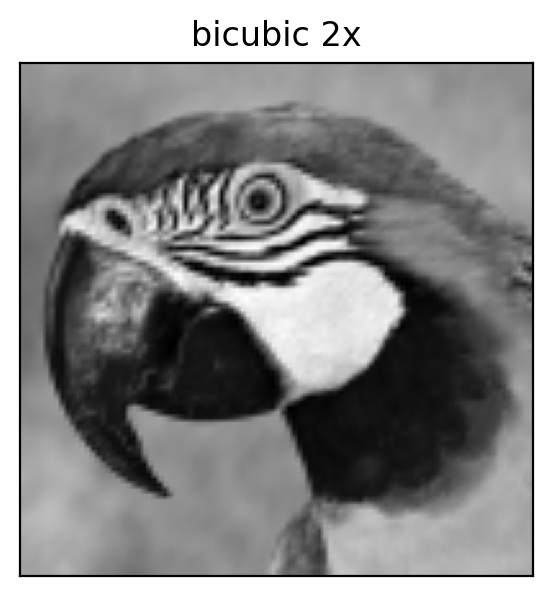

In [4]:
parrot = cv2.imread('parrot.bmp', cv2.IMREAD_GRAYSCALE)

imshow(bicubic_interpol(parrot, 2, 2), "bicubic 2x")
# imshow(bilinear_interpol(parrot, 2, 2), "bilinear 2x")

# firetruck = cv2.imread('firetruck.jpg', cv2.IMREAD_GRAYSCALE)
# imshow(bicubic_interpol(firetruck, 1.2, 1.2), "bicubic 1.2x")
# imshow(bilinear_interpol(firetruck, 1.2, 1.2), "bilinear 1.2x")

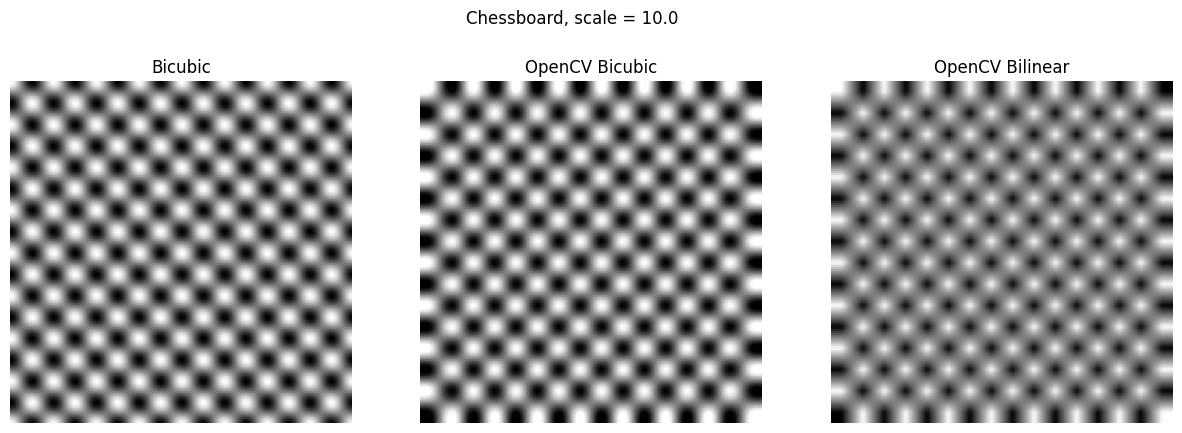

In [5]:
chess = cv2.imread('chessboard.bmp', cv2.IMREAD_GRAYSCALE)
fig, axs = plt.subplots(1,3, figsize=(15,5))
scale = 10.0
axs[0].imshow(bicubic_interpol(chess, scale, scale), cmap="gray")
axs[0].set_title("Bicubic")

axs[1].imshow(cv2.resize(chess, (round(chess.shape[1]*scale), round(chess.shape[0]*scale)),
                         interpolation=cv2.INTER_CUBIC), cmap="gray")
axs[1].set_title("OpenCV Bicubic")
axs[2].imshow(cv2.resize(chess, (round(chess.shape[1]*scale), round(chess.shape[0]*scale)),
                         interpolation=cv2.INTER_LINEAR), cmap="gray")

axs[2].set_title("OpenCV Bilinear")
for ax in axs:
  ax.set_xticks([])
  ax.set_yticks([])
  ax.axis('off')

fig.suptitle(f"Chessboard, scale = {scale}")
plt.show()


Liczba operacji dla pojedynczego piksela bikubiczna:
- 16 odczytów z pamięci
- pochodne: 4+4+4 = 12 mnożeń, 4*1+4*1+4*3 = 20
- wyliczenie rozwiązania układu równań: 256 mnożeń, 240 dodawań
- finalne wyliczenie: 6+6+16=28 mnożeń, 15 dodawań
- łącznie: 296 mnożeń, 275 dodawań

Liczba operacji dla pojedynczego piksela biliniowa:
- 4 odczyty z pamięci
- 6 mnożenia, 3 dodawania